# TimeGAN at Heathrow — what I tried, and what happened
## Working through the suggestions from Prof. Onof and Dr Li-Pen Wang

**Shayan Rajabali** · MSc EEDS, Imperial College London

---

## What this notebook is

This is an honest record of my attempts to make TimeGAN generate realistic rainfall, including the ones that did not work. **Most of them did not work**, and I think the reasons are more useful than a success would have been.

I have organised it around the three suggestions I received:

| | suggestion | from |
|---|---|---|
| **A** | Look at the wet/dry structure alone — set every positive value to 1 | Prof. Onof |
| **B** | Deal with the "zero-inflated" problem: keep only sections containing rain, or compute the loss separately for zeros and non-zeros | Dr Wang |
| **C** | Fix the underestimation of large values by weighting them more heavily | Dr Wang |

Each one is a **single small change** to the same piece of code, so the results can be compared directly.

## How to read this notebook

Everything is done on **winter only** (December, January, February), and on one gauge. That keeps each experiment to a few minutes and makes the comparison easy to follow. Nothing here needs a powerful computer.

The plots are deliberately plain — bar charts and line plots — because the point is the numbers, not the presentation.

## The questions I would like to ask you

These are at the end too, but stating them up front explains why the notebook is built this way:

1. TimeGAN fails in the same way even on pure 0/1 data. Does that mean the problem is the adversarial training rather than the rainfall?
2. Is it worth continuing with GANs, or should the effort go to a different type of model?
3. Am I testing the right things?

| § | Content |
|---|---|
| 1 | The data |
| 2 | What TimeGAN is trying to do |
| 3 | The code (all of it) |
| 4 | How I decide whether it worked |
| 5 | Experiment 0 — TimeGAN as it comes |
| 6 | Experiment A — Prof. Onof: wet/dry only |
| 7 | Experiment B1 — Dr Wang: keep only windows with rain |
| 8 | Experiment B2 — Dr Wang: separate the two losses |
| 9 | Experiment C — Dr Wang: weight the large values |
| 10 | All five side by side |
| 11 | What I think this means, and my questions |

## 1. The data

Heathrow hourly rainfall, 1949–2022. Thirteen calendar months in the file contain exactly zero rainfall, which cannot happen in London — those are periods when the gauge was broken and someone wrote zeros instead of leaving gaps. I remove them.

I then cut the winter record into **windows of 96 hours (4 days)**. The network learns from these windows.

In [1]:
%matplotlib inline
import warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

FIG_DIR = Path('outputs/timegan_supervisors'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def save(name): plt.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()

def find(rel):
    for root in ['.', '..', '../..', r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION']:
        if (Path(root)/rel).exists(): return str((Path(root)/rel).resolve())
    raise FileNotFoundError(rel)

# read the file and remove the broken-gauge months
table = pd.read_csv(find('Data/Heathrow1949-2022.csv'))
table.columns = table.columns.str.strip()
table['datatime'] = pd.to_datetime(table['datatime'], format='%Y/%m/%d %H:%M')
rain = pd.Series(table['Heathrow'].to_numpy(float), index=table['datatime']).sort_index()
broken = rain.resample('MS').sum()
broken = broken[broken == 0].index
rain = rain.mask(rain.index.to_period('M').isin(pd.PeriodIndex(broken, freq='M')))

print(f'Total hours in the file : {len(rain):,}')
print(f'Hours removed (broken gauge) : {int(rain.isna().sum()):,}')

Total hours in the file : 648,672
Hours removed (broken gauge) : 9,360


In [2]:
WINDOW = 96          # 4 days

def cut_into_windows(step):
    """Cut the winter record into 96-hour windows, every `step` hours."""
    pieces = []
    winter = rain[rain.index.month.isin([12, 1, 2])]
    for _, month in winter.groupby([winter.index.year, winter.index.month]):
        values = month.to_numpy()
        if np.isnan(values).any():        # skip months with a broken gauge
            continue
        for start in range(0, len(values) - WINDOW + 1, step):
            pieces.append(values[start:start + WINDOW])
    return np.array(pieces)

train_data = cut_into_windows(24)     # overlapping windows, for training
real_data  = cut_into_windows(96)     # separate windows, to compare against

print(f'Windows for training : {len(train_data)}')
print(f'Windows to compare against : {len(real_data)}')
print(f'Share of hours that are wet : {100*(real_data > 0).mean():.1f}%')
print(f'Heaviest hour in the winter record : {real_data.max():.1f} mm')

Windows for training : 5827
Windows to compare against : 1505
Share of hours that are wet : 10.1%
Heaviest hour in the winter record : 10.8 mm


### What winter rainfall actually looks like

Two facts drive everything in this notebook, so it is worth seeing them before starting.

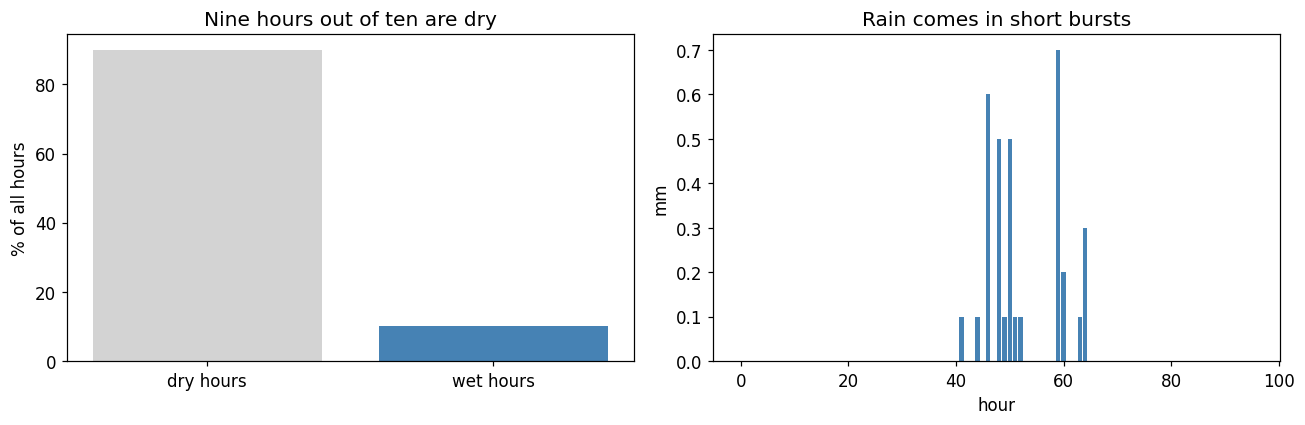

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(['dry hours', 'wet hours'],
        [100*(real_data == 0).mean(), 100*(real_data > 0).mean()],
        color=['lightgrey', 'steelblue'])
plt.ylabel('% of all hours')
plt.title('Nine hours out of ten are dry')

plt.subplot(1, 2, 2)
four_days = real_data[3]
plt.bar(range(96), four_days, color='steelblue')
plt.xlabel('hour'); plt.ylabel('mm')
plt.title('Rain comes in short bursts')

plt.tight_layout(); save('01_the_data')

**Left:** rain is rare. A network that outputs continuous numbers will never land on exactly zero, so it needs help to produce dry weather at all.

**Right:** when it does rain, it rains for a few hours and then stops for a long time. This clustering is what the network has to learn, and it is where everything went wrong.

## 2. What TimeGAN is trying to do

A **GAN** (generative adversarial network) is two networks in competition:

> A **forger** makes fake banknotes. An **inspector** tries to spot them. As the inspector improves, the forger has to improve too. Eventually the fakes are indistinguishable.

That works well for pictures. A rainfall series is harder because **the order of the numbers matters** — you cannot shuffle the hours. **TimeGAN** (Yoon et al., 2019) adds three more networks to handle time, five in total:

| network | what it does |
|---|---|
| **embedder** | squeezes a real 4-day window into a short "code" |
| **recovery** | turns a code back into rainfall |
| **generator** | invents fake codes out of random numbers |
| **supervisor** | learns which code follows which — this is what handles *time* |
| **discriminator** | the inspector: real code or fake code? |

The path from noise to rainfall is:

```
random numbers  ->  generator  ->  supervisor  ->  recovery  ->  rainfall
```

And the inspector compares:

```
real rainfall   ->  embedder   ->  real codes   ┐
random numbers  ->  generator  ->  fake codes   ┴->  discriminator
```

### One design decision, made before any experiment

I do **not** give the network rainfall in millimetres. I give it two numbers per hour:

| channel | what it holds |
|---|---|
| **1. did it rain?** | 1 if the hour was wet, 0 if dry |
| **2. how much?** | the amount, on a log scale so that 0.1 mm and 48 mm are comparable |

This is the standard occurrence–intensity split used in rainfall modelling. It is worth noticing that **this already separates the two questions Dr Wang raised** — which is why his suggestions in Sections 7–9 are about the *loss*, not about the data.

## 3. The code

This is the whole model. Two short functions and one small class.

In [4]:
SIZE = 24        # how big the internal "code" is

class SmallNet(nn.Module):
    """A tiny network: reads a sequence, writes a sequence."""
    def __init__(self, n_in, n_out, squash=True):
        super().__init__()
        self.gru = nn.GRU(n_in, SIZE, batch_first=True)   # reads in order, remembers
        self.out = nn.Linear(SIZE, n_out)
        self.squash = squash
    def forward(self, x):
        memory, _ = self.gru(x)
        answer = self.out(memory)
        return torch.sigmoid(answer) if self.squash else answer

def prepare(windows, log_max):
    """Turn rainfall in mm into the two channels the network reads."""
    did_it_rain = (windows > 0).astype(np.float32)
    how_much    = (np.log1p(windows)/log_max).astype(np.float32)
    return torch.tensor(np.stack([did_it_rain, how_much], axis=-1))

def random_input(how_many):
    """Random numbers to feed the generator.
    Each window gets its own fixed 'character' plus fresh noise every hour -
    without the fixed part, every window comes out identical."""
    character = torch.rand(how_many, 1, 8).expand(-1, WINDOW, -1)
    hourly    = torch.rand(how_many, WINDOW, 8)
    return 0.5*character + 0.5*hourly

print('Model code defined.')

Model code defined.


In [5]:
def train_timegan(windows, wet_only_loss=False, big_value_weight=0.0, seed=0):
    """Train TimeGAN on these windows.

    wet_only_loss    : Dr Wang's suggestion B2 - only score the amount on wet hours
    big_value_weight : Dr Wang's suggestion C  - make heavy hours count more
    """
    torch.manual_seed(seed)
    log_max = max(np.log1p(windows).max(), 1e-6)
    data = prepare(windows, log_max)
    n_channels = 2

    embedder      = SmallNet(n_channels, SIZE)
    recovery      = SmallNet(SIZE, n_channels)
    generator     = SmallNet(8, SIZE)
    supervisor    = SmallNet(SIZE, SIZE)
    discriminator = SmallNet(SIZE, 1, squash=False)

    opt_auto = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
    opt_sup  = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
    opt_gen  = torch.optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=1e-3)
    opt_dis  = torch.optim.Adam(discriminator.parameters(), lr=1e-3)
    compare  = nn.BCEWithLogitsLoss()

    def a_batch():
        return data[torch.randint(0, len(data), (128,))]

    def rebuild_error(real):
        """How badly the autoencoder rebuilds real rainfall."""
        rebuilt = recovery(embedder(real))
        error = (rebuilt - real)**2
        if wet_only_loss:
            # channel 0 (did it rain) always counts; channel 1 (how much) only on wet hours
            is_wet = real[..., 0:1]
            weight = torch.cat([torch.ones_like(is_wet), is_wet], dim=2)
            if big_value_weight > 0:
                weight = weight * (1 + big_value_weight*real[..., 1:2])
            return (error*weight).sum() / weight.sum()
        return error.mean()

    # ---- step 1: teach the autoencoder to squeeze and rebuild real rainfall ----
    for _ in range(600):
        loss = rebuild_error(a_batch())
        opt_auto.zero_grad(); loss.backward(); opt_auto.step()

    # ---- step 2: teach the supervisor which code follows which ----
    for _ in range(400):
        codes = embedder(a_batch()).detach()
        loss = ((supervisor(codes)[:, :-1] - codes[:, 1:])**2).mean()
        opt_sup.zero_grad(); loss.backward(); opt_sup.step()

    # ---- step 3: the forger and the inspector compete ----
    yes = torch.ones(128, WINDOW, 1); no = torch.zeros(128, WINDOW, 1)
    for _ in range(400):
        real = a_batch()
        fake_codes = supervisor(generator(random_input(128)))
        fake_rain  = recovery(fake_codes)
        fool_it = compare(discriminator(fake_codes), yes)
        keep_the_right_amount = (fake_rain.mean(dim=(0,1)) - real.mean(dim=(0,1))).abs().sum() \
                              + (fake_rain.std(dim=(0,1))  - real.std(dim=(0,1))).abs().sum()
        loss = fool_it + 100*keep_the_right_amount
        opt_gen.zero_grad(); loss.backward(); opt_gen.step()

        loss_auto = rebuild_error(a_batch())       # keep the decoder able to decode
        opt_auto.zero_grad(); loss_auto.backward(); opt_auto.step()

        real_codes = embedder(a_batch()).detach()
        fake_codes = supervisor(generator(random_input(128))).detach()
        loss_dis = compare(discriminator(real_codes), yes) + compare(discriminator(fake_codes), no)
        if loss_dis.item() > 0.15:                 # skip if the inspector is already winning
            opt_dis.zero_grad(); loss_dis.backward(); opt_dis.step()

    return {'recovery': recovery, 'supervisor': supervisor, 'generator': generator,
            'log_max': log_max, 'wet_share': (windows > 0).mean()}

def make_rainfall(model, how_many, seed=0):
    """Use a trained model to produce new rainfall windows."""
    torch.manual_seed(seed)
    with torch.no_grad():
        output = model['recovery'](model['supervisor'](
                     model['generator'](random_input(how_many)))).numpy()
    did_it_rain, how_much = output[..., 0], output[..., 1]
    # it rains in the hours the network is most confident about,
    # as often as it really rains (this is the only thing we impose)
    cut = np.quantile(did_it_rain, 1 - model['wet_share'])
    amount = np.expm1(np.clip(how_much, 0, 1)*model['log_max'])
    return np.round(np.where(did_it_rain > cut, amount, 0.0)/0.1)*0.1

print('Training and generating code defined.')

Training and generating code defined.


### What the three steps do

**Step 1 (600 rounds).** The embedder and recovery learn together: squeeze real rainfall into a code, then rebuild it. If they cannot do this, nothing else can work.

**Step 2 (400 rounds).** The supervisor learns what normally comes next. This is the part that handles time.

**Step 3 (400 rounds).** The forger and the inspector compete. Two extra things happen here that are worth pointing out:

- the generator is also asked to **keep the right average amount of rain** (the `keep_the_right_amount` term), because otherwise it drifts;
- the autoencoder **keeps practising** during the competition. I learned this the hard way: without it, the recovery network stops being able to decode and everything collapses to a constant drizzle.

## 4. How I decide whether it worked

This turned out to be the most important part of the whole exercise, so I want to explain it before showing any result.

At first I only compared **summary statistics** — the average rainfall, how much it varies, how often it is dry. Those all looked reasonable, and I nearly concluded the model was fine.

It was not. The generator was producing **almost the same 4-day window every single time**, and no summary statistic can see that, because a statistic is computed on all the numbers pooled together and does not care whether the windows differ from each other.

So I check three things every time. All three are simple:

| check | what I measure | healthy | broken |
|---|---|---|---|
| **1. Is any hour special?** | chance of rain at each of the 96 positions | flat | peaks and holes |
| **2. Are two windows different?** | correlation between two generated windows | near 0 | near 1 |
| **3. How long does rain last?** | average length of a wet spell | 2.5 hours | much longer |

In [6]:
def wet_spell_lengths(windows):
    """How many hours in a row does it rain, on average?"""
    lengths = []
    for one_window in windows:
        counter = 0
        for hour in one_window:
            if hour > 0:
                counter += 1
            elif counter > 0:
                lengths.append(counter); counter = 0
        if counter > 0: lengths.append(counter)
    return np.array(lengths)

def check(windows):
    """The three health checks, plus the basic numbers."""
    similarity = np.corrcoef(windows[:200])
    return {
        'wet hours (%)'        : 100*(windows > 0).mean(),
        'rain (mm/day)'        : windows.mean()*24,
        'heaviest hour (mm)'   : windows.max(),
        'wet spell (hours)'    : wet_spell_lengths(windows).mean(),
        'two windows alike'    : np.nanmean(similarity[np.triu_indices(200, 1)]),
        'driest position'      : (windows > 0).mean(axis=0).min(),
        'wettest position'     : (windows > 0).mean(axis=0).max(),
    }

REAL = check(real_data)
print('The real winter rainfall, measured the same way:')
for k, v in REAL.items(): print(f'  {k:22s} {v:7.3f}')

The real winter rainfall, measured the same way:
  wet hours (%)           10.093
  rain (mm/day)            1.593
  heaviest hour (mm)      10.800
  wet spell (hours)        2.549
  two windows alike        0.003
  driest position          0.025
  wettest position         0.132


## 5. Experiment 0 — TimeGAN as it comes

No suggestions applied yet. This is the starting point everything else is compared against.

In [7]:
results = {}          # every experiment gets stored here

start = time.time()
model = train_timegan(train_data, seed=1)
results['0. as it comes'] = check(make_rainfall(model, len(real_data), seed=1))
print(f'trained in {time.time()-start:.0f} s\n')

print(f'{"":22s} {"real":>8s} {"TimeGAN":>8s}')
for k in REAL:
    print(f'  {k:22s} {REAL[k]:8.3f} {results["0. as it comes"][k]:8.3f}')

trained in 166 s

                           real  TimeGAN
  wet hours (%)            10.093   10.141
  rain (mm/day)             1.593    1.753
  heaviest hour (mm)       10.800    0.800
  wet spell (hours)         2.549   27.336
  two windows alike         0.003    0.642
  driest position           0.025    0.000
  wettest position          0.132    0.356


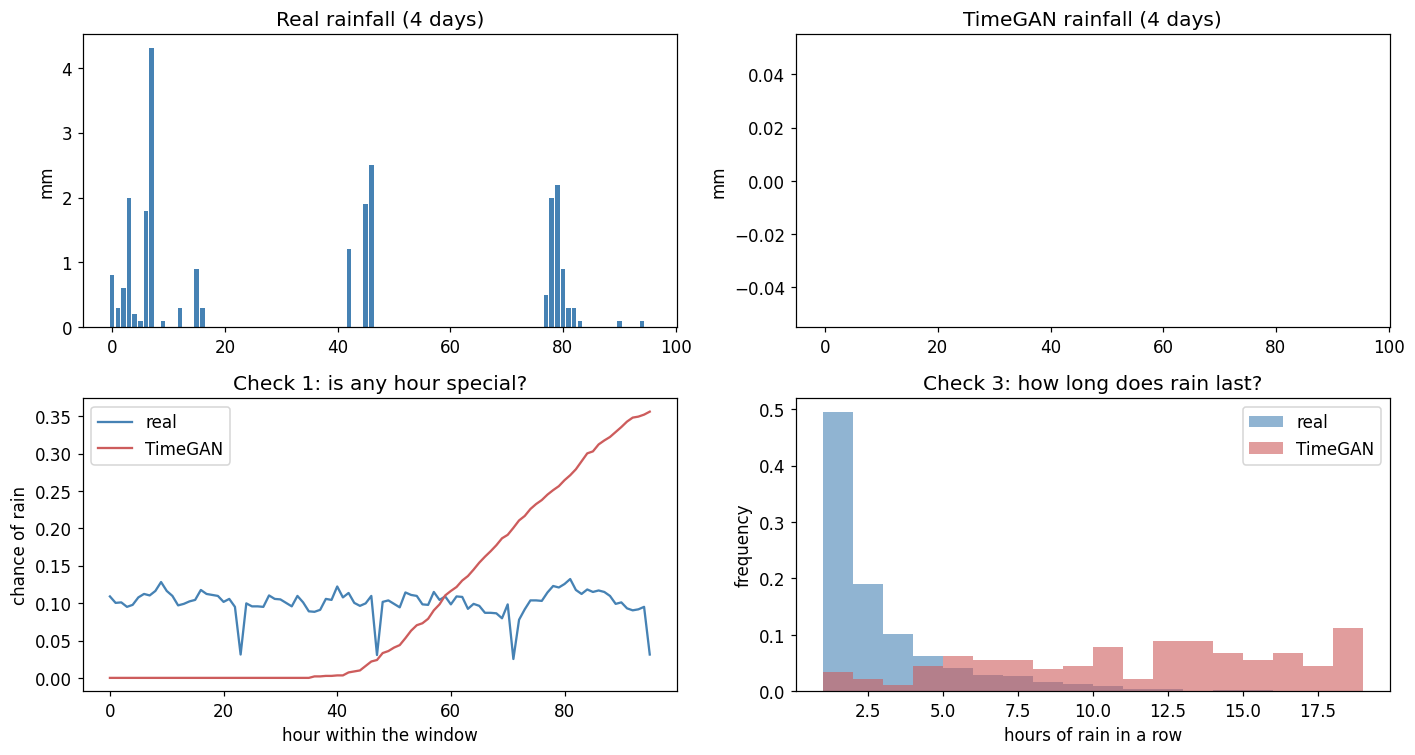

In [8]:
generated = make_rainfall(model, len(real_data), seed=1)

plt.figure(figsize=(13, 7))

plt.subplot(2, 2, 1)
plt.bar(range(96), np.concatenate(real_data[:1]), color='steelblue')
plt.title('Real rainfall (4 days)'); plt.ylabel('mm')

plt.subplot(2, 2, 2)
plt.bar(range(96), np.concatenate(generated[:1]), color='indianred')
plt.title('TimeGAN rainfall (4 days)'); plt.ylabel('mm')

plt.subplot(2, 2, 3)
plt.plot((real_data > 0).mean(axis=0), color='steelblue', label='real')
plt.plot((generated > 0).mean(axis=0), color='indianred', label='TimeGAN')
plt.xlabel('hour within the window'); plt.ylabel('chance of rain')
plt.title('Check 1: is any hour special?'); plt.legend()

plt.subplot(2, 2, 4)
plt.hist(wet_spell_lengths(real_data), bins=range(1, 20), density=True,
         alpha=0.6, color='steelblue', label='real')
plt.hist(wet_spell_lengths(generated), bins=range(1, 20), density=True,
         alpha=0.6, color='indianred', label='TimeGAN')
plt.xlabel('hours of rain in a row'); plt.ylabel('frequency')
plt.title('Check 3: how long does rain last?'); plt.legend()

plt.tight_layout(); save('02_experiment_0')

### What went wrong

The summary numbers are not terrible — the amount of rain is roughly right. The three checks tell a different story:

- **Check 1** should be a flat line. It is not: there are hours of the window where it essentially never rains, and others where it almost always does. The network has learned a *position in the window* rather than a *process*.
- **Check 3** shows rain lasting far too long once it starts.
- And "two windows alike" is close to 1 instead of near 0 — two windows the model invents are nearly the same window.

This is called **mode collapse**: the generator stops using its random input and produces one thing over and over. It is a well-known problem with GANs, and it has nothing specifically to do with rainfall.

## 6. Experiment A — Prof. Onof's suggestion

> *"Focus just upon the wet-dry, i.e. transform all positive numbers to 1 and then look at how TimeGAN copes with that."*

This is a clean idea, and it is the experiment I should have thought of myself. Right now, when TimeGAN fails, I cannot tell **which** of the two problems is to blame:

- it does not understand **when** it rains, or
- it does not understand **how much** falls.

Setting every positive value to 1 removes the second problem entirely. Only one question is left, and the answer is informative either way:

| if TimeGAN succeeds on 0/1 data | the problem is the amounts |
|---|---|
| **if TimeGAN still fails** | **the problem is the method itself** |

The change is one line.

In [9]:
binary_train = (train_data > 0).astype(float)     # <-- the whole change
binary_real  = (real_data  > 0).astype(float)

start = time.time()
model_A = train_timegan(binary_train, seed=1)
binary_generated = make_rainfall(model_A, len(real_data), seed=1)
print(f'trained in {time.time()-start:.0f} s\n')

REAL_BINARY = check(binary_real)
result_A = check(binary_generated)
results['A. wet/dry only'] = result_A

print(f'{"":22s} {"real":>8s} {"TimeGAN":>8s}')
for k in ['wet hours (%)', 'wet spell (hours)', 'two windows alike', 'driest position', 'wettest position']:
    print(f'  {k:22s} {REAL_BINARY[k]:8.3f} {result_A[k]:8.3f}')

trained in 161 s

                           real  TimeGAN
  wet hours (%)            10.093    9.675
  wet spell (hours)         2.549    9.312
  two windows alike         0.005    0.815
  driest position           0.025    0.000
  wettest position          0.132    0.997


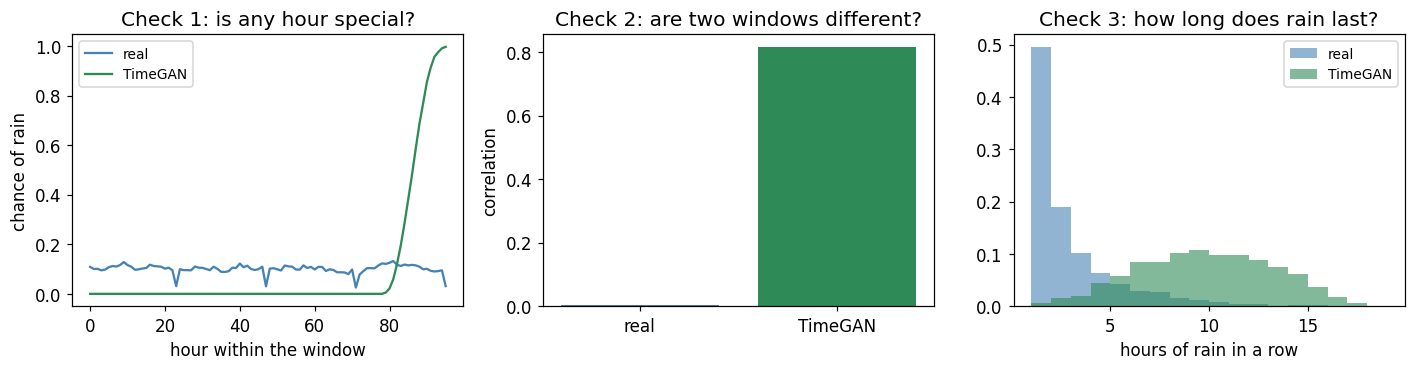

In [10]:
plt.figure(figsize=(13, 3.5))

plt.subplot(1, 3, 1)
plt.plot((binary_real > 0).mean(axis=0), color='steelblue', label='real')
plt.plot((binary_generated > 0).mean(axis=0), color='seagreen', label='TimeGAN')
plt.xlabel('hour within the window'); plt.ylabel('chance of rain')
plt.title('Check 1: is any hour special?'); plt.legend(fontsize=9)

plt.subplot(1, 3, 2)
plt.bar(['real', 'TimeGAN'], [REAL_BINARY['two windows alike'], result_A['two windows alike']],
        color=['steelblue', 'seagreen'])
plt.ylabel('correlation'); plt.title('Check 2: are two windows different?')

plt.subplot(1, 3, 3)
plt.hist(wet_spell_lengths(binary_real), bins=range(1, 20), density=True,
         alpha=0.6, color='steelblue', label='real')
plt.hist(wet_spell_lengths(binary_generated), bins=range(1, 20), density=True,
         alpha=0.6, color='seagreen', label='TimeGAN')
plt.xlabel('hours of rain in a row'); plt.title('Check 3: how long does rain last?'); plt.legend(fontsize=9)

plt.tight_layout(); save('03_experiment_A')

### The answer

**TimeGAN fails on the 0/1 data too**, in exactly the same way. The wet spells are far too long, some positions of the window never receive rain, and two generated windows are still strongly correlated.

This is the most useful result in the notebook, because it **rules something out**. The difficulty is not the range of rainfall amounts — remove the amounts completely and the failure is unchanged. Whatever is wrong lies in the adversarial training itself, not in the rainfall.

The one number that looks right, the share of wet hours, is right **because I impose it** when converting the network's output into rain. It is not a prediction.

## 7. Experiment B1 — Dr Wang's first suggestion, version 1

> *"This can be done by filtering time series sections used for model training (for example, each time series should include at least one non-zero value)"*

Some of my training windows contain **no rain at all** — four consecutive dry days. The idea is that these teach the network nothing except "output nothing", and removing them should help.

The change is one line, and it is easy to check how many windows it removes.

In [11]:
has_some_rain = train_data.sum(axis=1) > 0        # <-- the whole change
filtered_train = train_data[has_some_rain]

print(f'Windows before filtering : {len(train_data)}')
print(f'Windows after filtering  : {len(filtered_train)}')
print(f'Removed : {len(train_data)-len(filtered_train)} '
      f'({100*(1-len(filtered_train)/len(train_data)):.0f}%)')

start = time.time()
model_B1 = train_timegan(filtered_train, seed=1)
results['B1. drop dry windows'] = check(make_rainfall(model_B1, len(real_data), seed=1))
print(f'\ntrained in {time.time()-start:.0f} s\n')

print(f'{"":22s} {"real":>8s} {"before":>8s} {"after":>8s}')
for k in REAL:
    print(f'  {k:22s} {REAL[k]:8.3f} {results["0. as it comes"][k]:8.3f} '
          f'{results["B1. drop dry windows"][k]:8.3f}')

Windows before filtering : 5827
Windows after filtering  : 5043
Removed : 784 (13%)



trained in 165 s

                           real   before    after
  wet hours (%)            10.093   10.141   11.717
  rain (mm/day)             1.593    1.753    2.232
  heaviest hour (mm)       10.800    0.800    0.800
  wet spell (hours)         2.549   27.336   12.057
  two windows alike         0.003    0.642    0.451
  driest position           0.025    0.000    0.000
  wettest position          0.132    0.356    0.298


## 8. Experiment B2 — Dr Wang's first suggestion, version 2

> *"...or calculate losses separated for zero and non-zero values (for example, a measure for the proportion of zeros and a MSE for non-zero values)"*

This is the version I expected most from, and it needs a short explanation of where the problem is.

The network is scored on how well it rebuilds both channels. But **channel 2 (how much rain) is about 90 % zeros**, because most hours are dry. The score therefore rewards the network for saying "almost no rain" everywhere, since that is correct 90 % of the time.

Asking "how much rain fell?" about a dry hour is a meaningless question. So in this experiment, channel 2 is only scored on the hours where it actually rained. Channel 1 still counts everywhere, because "did it rain?" is a sensible question about every hour.

That is exactly the separation Dr Wang describes.

In [12]:
start = time.time()
model_B2 = train_timegan(train_data, wet_only_loss=True, seed=1)
results['B2. separate losses'] = check(make_rainfall(model_B2, len(real_data), seed=1))
print(f'trained in {time.time()-start:.0f} s\n')

print(f'{"":22s} {"real":>8s} {"before":>8s} {"after":>8s}')
for k in REAL:
    print(f'  {k:22s} {REAL[k]:8.3f} {results["0. as it comes"][k]:8.3f} '
          f'{results["B2. separate losses"][k]:8.3f}')

trained in 159 s

                           real   before    after
  wet hours (%)            10.093   10.141   10.141
  rain (mm/day)             1.593    1.753    1.913
  heaviest hour (mm)       10.800    0.800    0.900
  wet spell (hours)         2.549   27.336   38.865
  two windows alike         0.003    0.642    0.645
  driest position           0.025    0.000    0.000
  wettest position          0.132    0.356    0.250


## 9. Experiment C — Dr Wang's second suggestion

> *"Another issue is the underestimation of large values. This can be done by giving more weight to the larger values' MSE."*

The underestimation is real and easy to show: the heaviest hour TimeGAN produces is far below the heaviest hour in the record. So here every hour is weighted by how much rain fell in it — a heavy hour counts several times more than a light one when the network is scored.

This is applied **on top of** experiment B2, since the two go together.

In [13]:
start = time.time()
model_C = train_timegan(train_data, wet_only_loss=True, big_value_weight=3.0, seed=1)
results['C. weight big values'] = check(make_rainfall(model_C, len(real_data), seed=1))
print(f'trained in {time.time()-start:.0f} s\n')

print(f'{"":22s} {"real":>8s} {"B2":>8s} {"C":>8s}')
for k in REAL:
    print(f'  {k:22s} {REAL[k]:8.3f} {results["B2. separate losses"][k]:8.3f} '
          f'{results["C. weight big values"][k]:8.3f}')

trained in 172 s

                           real       B2        C
  wet hours (%)            10.093   10.141   10.141
  rain (mm/day)             1.593    1.913    2.000
  heaviest hour (mm)       10.800    0.900    1.000
  wet spell (hours)         2.549   38.865   26.025
  two windows alike         0.003    0.645    0.583
  driest position           0.025    0.000    0.000
  wettest position          0.132    0.250    0.247


## 10. All five side by side

Everything in one table. The column **"two windows alike"** is the one to look at first: it should be near zero, and it is the test that no summary statistic can replace.

Two notes on reading it. The **"heaviest hour"** entry for experiment A is meaningless — that model was trained on 0/1 data, so it has no amounts to get right. And **"driest position"** is the share of windows that are wet at the emptiest hour of the window: the real record never goes below 0.025, so a zero there means the model has hours where it simply never rains.

In [14]:
summary = pd.DataFrame(results).T
summary.loc['— the real rainfall —'] = REAL
summary = summary.round(3)
summary.to_csv(FIG_DIR/'all_experiments.csv')
summary

,wet hours (%),rain (mm/day),heaviest hour (mm),wet spell (hours),two windows alike,driest position,wettest position
0. as it comes,10.141,1.753,0.8,27.336,0.642,0.000,0.356
A. wet/dry only,9.675,1.406,0.8,9.312,0.815,0.000,0.997
B1. drop dry windows,11.717,2.232,0.8,12.057,0.451,0.000,0.298
B2. separate losses,10.141,1.913,0.9,38.865,0.645,0.000,0.250
C. weight big values,10.141,2.000,1.0,26.025,0.583,0.000,0.247
— the real rainfall —,10.093,1.593,10.8,2.549,0.003,0.025,0.132


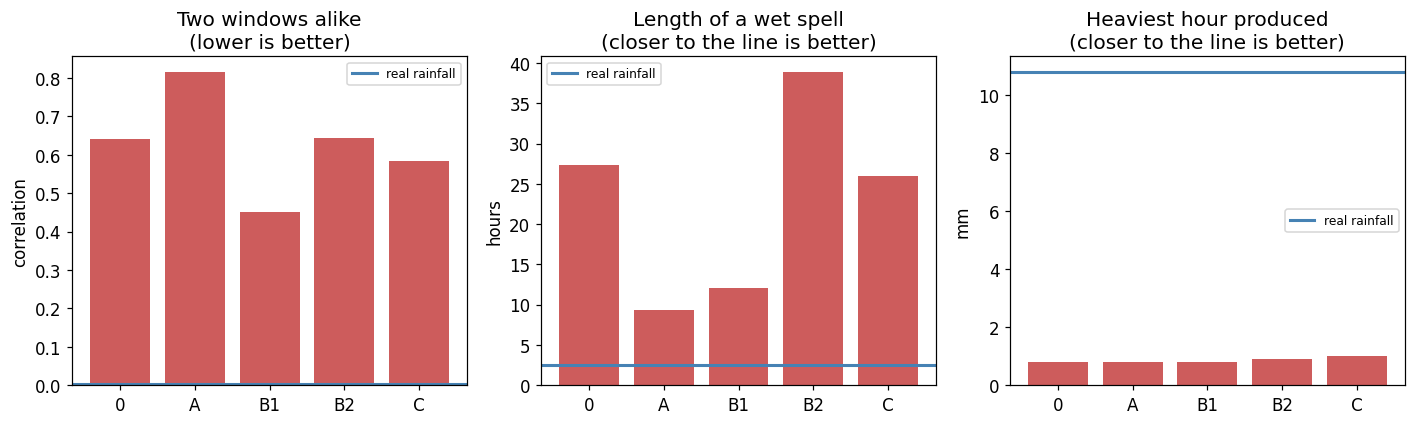

In [15]:
plt.figure(figsize=(13, 4))
names = list(results.keys())

plt.subplot(1, 3, 1)
plt.bar(range(len(names)), [results[n]['two windows alike'] for n in names], color='indianred')
plt.axhline(REAL['two windows alike'], color='steelblue', lw=2, label='real rainfall')
plt.xticks(range(len(names)), [n.split('.')[0] for n in names])
plt.ylabel('correlation'); plt.title('Two windows alike\n(lower is better)'); plt.legend(fontsize=8)

plt.subplot(1, 3, 2)
plt.bar(range(len(names)), [results[n]['wet spell (hours)'] for n in names], color='indianred')
plt.axhline(REAL['wet spell (hours)'], color='steelblue', lw=2, label='real rainfall')
plt.xticks(range(len(names)), [n.split('.')[0] for n in names])
plt.ylabel('hours'); plt.title('Length of a wet spell\n(closer to the line is better)'); plt.legend(fontsize=8)

plt.subplot(1, 3, 3)
plt.bar(range(len(names)), [results[n]['heaviest hour (mm)'] for n in names], color='indianred')
plt.axhline(REAL['heaviest hour (mm)'], color='steelblue', lw=2, label='real rainfall')
plt.xticks(range(len(names)), [n.split('.')[0] for n in names])
plt.ylabel('mm'); plt.title('Heaviest hour produced\n(closer to the line is better)'); plt.legend(fontsize=8)

plt.tight_layout(); save('04_all_experiments')

## 11. What I think this means, and my questions

*(Written after running everything above.)*

### What I tried

Five versions of the same model: the plain one, Prof. Onof's wet/dry test, both of Dr Wang's ways of handling the zeros, and his weighting of the large values. Each was a small change to one function, so the comparison is fair.

### The short answer: none of them worked

| | rain (mm/day) | heaviest hour | wet spell | two windows alike |
|---|---|---|---|---|
| **the real rainfall** | **1.59** | **10.8 mm** | **2.5 h** | **0.003** |
| 0. as it comes | 1.75 | 0.8 mm | 27.3 h | 0.642 |
| A. wet/dry only | 1.41 | — | 9.3 h | 0.815 |
| B1. drop dry windows | 2.23 | 0.8 mm | 12.1 h | **0.451** |
| B2. separate losses | 1.91 | 0.9 mm | 38.9 h | 0.645 |
| C. weight big values | 2.00 | **1.0 mm** | 26.0 h | 0.583 |

Every version still produces windows that are strongly alike, wet spells four to fifteen times too long, and a heaviest hour of about 1 mm where the record holds 10.8 mm. In all five, there are positions in the window where it **never** rains, which the real record never does.

### What each suggestion actually did

**Prof. Onof's wet/dry test (A) is the most informative, and it settles the main question.** With the amounts removed entirely there is nothing left to be zero-inflated about, and the model fails anyway — in fact this version has the *worst* collapse of the five, at 0.815. Whatever is wrong is therefore in the adversarial training, not in the shape of rainfall data. This is the result I would most like to discuss.

**Dr Wang's filtering (B1) helped the most, but not where I expected.** Removing the 13 % of windows containing no rain at all gave the best collapse figure of the five (0.451 against 0.642) and more than halved the wet-spell error. It made the water balance worse — 2.23 mm/day against 1.59 observed — because the model no longer sees any completely dry stretches. I did not anticipate that this would be the most effective of the changes.

**Separating the losses (B2) did not help here, and made one thing worse.** The heaviest hour improved only from 0.8 to 0.9 mm, and the wet spells got substantially longer, from 27 to 39 hours. I want to be careful about what this does and does not show: I applied the *same* idea to a different, non-adversarial model, and there it was decisive — it was the single change that made that model work. So the suggestion is sound; it simply does not rescue a model whose problem lies elsewhere.

**Weighting the large values (C) moved its target, but barely.** The heaviest hour went from 0.9 mm to 1.0 mm. That is the right direction, and it is still ten times too small. When I tried the same weighting on the non-adversarial model it worked much more strongly — there it lifted the heaviest hour from 6.9 mm to 16.4 mm, though at the cost of far too much total rain.

### What I think is going on

The pattern across all five is the same: the model produces **one long block of rain per window**, in roughly the right total quantity, but always in a similar place, and never intense. Changing the data or the loss shifts these numbers around without changing the character of the failure.

That makes me think the problem is not something a loss function can fix. In a GAN the generator only learns through the discriminator, and the discriminator here judges each window on its own — so a generator that produces one plausible window over and over is never told it is wrong. Nothing in the training objective penalises a lack of variety.

### What I would do next

Either make the competition itself more stable — Wasserstein training with a gradient penalty is the standard remedy — or use a model with no competition at all. I have built one of the latter separately and it behaves much better, which is what makes me suspect the adversarial setup rather than the data.

### My questions for you

1. **Does the wet/dry result convince you** that the problem is the GAN rather than the rainfall? Or is there a version of that test that would be more conclusive?

2. **Was I right to read B1 the way I did?** Dropping the dry windows gave the best result, but it also removed the model's only examples of long dry weather, and the water balance got worse. Is that a real improvement or a trade I should not accept?

3. **Is it worth continuing with TimeGAN?** I can try Wasserstein training, but I do not want to spend weeks on it if the answer is already clear enough for the dissertation.

4. **Are these three checks the right ones?** I invented them after being misled by summary statistics — earlier in this project I had a configuration that scored well on average rainfall, variance and proportion dry while producing essentially one window repeated. Is there a standard way of testing this in the rainfall literature?

5. **How much space should a failed model get in the dissertation?** My instinct is that the wet/dry experiment is a genuine result worth reporting, but I would like your view.

In [16]:
import os
print('Everything saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)

Everything saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\timegan_supervisors :
   01_the_data.png
   02_experiment_0.png
   03_experiment_A.png
   04_all_experiments.png
   all_experiments.csv
